# 01 — Stable rolling PCA: tracking the market's hidden factors through time

**Tool:** `quantroll.RollingPCA` · **Data:** daily returns of the nine S&P sector ETFs (XLK, XLF, XLE, XLV, XLI, XLP, XLY, XLU, XLB), 2012 → today, plus the real late-inception ETFs XLRE (2015) and XLC (2018) for the variable-universe section.

## The big picture: nonstationary markets and the rolling dilemma

Every statistical model of markets estimates some *structure*: how sectors co-move, what kind of environment we are in, which names behave alike. And every such structure shares one uncomfortable property — it is real, but it does not stay put. Correlations drift, leadership rotates, regimes come and go. That leaves the analyst two unattractive options:

- **Fit once, on all history.** You get a precise answer — about an *average* market that no longer exists.
- **Refit on a rolling window.** Now the answer adapts — but each window's answer arrives as a fresh, disconnected object. Nothing guarantees that "factor 2" computed today refers to the same thing as "factor 2" computed yesterday; often even the *sign* or the *ordering* of the answer is arbitrary, chosen anew at every refit.

The second option is the right instinct, and it is what practitioners actually do. The trouble is that the classical tools were designed to be fit *once*; re-run daily, they exercise their arbitrary choices differently each time, and the outputs merely *look* like time series — really they are stacks of unrelated snapshots.

This series of five notebooks develops the missing third option: **rolling estimation with continuity of identity**. Force each window's answer to be expressed in the same terms as the previous window's — same orientation, same ordering, same labels — and the outputs become genuine time series: things you can plot, monitor, set alerts on, feed to downstream models, and audit afterwards. That single idea — *stability is what turns analytics into infrastructure* — is the thread running through everything that follows. This first notebook develops it in the simplest and most consequential setting: principal component analysis of asset returns.

## What PCA gives us here

The daily returns of nine sector ETFs are highly correlated: on most days, when the market rises, most sectors rise with it. When variables move together like this, much of the information in nine numbers is redundant — and *principal component analysis* (PCA) is the standard tool for summarizing a set of correlated variables with a smaller number of new, uncorrelated ones.

The idea is simple to state. The *first principal component* (PC1) is the weighted combination of the nine returns,

$$z = \phi_1 x_1 + \phi_2 x_2 + \cdots + \phi_9 x_9,$$

whose variance is as large as possible, with the weights normalized so that $\sum_j \phi_j^2 = 1$ (otherwise we could make the variance arbitrarily large just by inflating the weights). The weights $\phi_j$ are called the *loadings*. Keep two nouns straight from here on, because they are the axis of the whole notebook:

- the **loadings** are the *recipe* — which sectors, with what weights, make up the component;
- the **scores** (or *projections*) are what the recipe *returns each day* — plug a particular day's nine returns into the formula above and $z$ is a single number for that day.

The *second* principal component is the highest-variance recipe among all those *uncorrelated* with the first, and so on. Computationally, the loading vectors are the eigenvectors of the covariance matrix of the returns — but the "directions of greatest common variation" intuition is all we will need.

In our setting the components have natural interpretations:

- **PC1 — "the market factor."** Because all sectors move together, the highest-variance recipe typically puts a same-signed weight on every sector: it *is* the common market movement. (Section 1 shows a rare live exception.) PCA also reports the *proportion of total variance explained* by each component, and PC1's share has its own name in finance — the *absorption ratio*. It is a well-known systemic-risk gauge: when one component absorbs most of the variance, everything is trading as one, and diversification is quietly failing. We return to it in section 5.
- **PC2, PC3 — relative-value factors.** Since they must be uncorrelated with "everything moves together," their loadings mix positive and negative signs: they are long some sectors and short others (defensive vs. cyclical, energy vs. technology, and so on). Their loadings tell us what the market is currently differentiating on.
- **Factor return series — the *projections*.** This is the scores idea, applied day after day. Take PC1's recipe and apply it to Monday's returns: one number, the market factor's return on Monday. Apply it to Tuesday's, Wednesday's, … and PC1 becomes a *return series of its own* — likewise PC2 becomes the daily return of its long/short recipe. These derived series, not the loadings, are what you feed to risk models, hedges, and signals; section 1 shows them as an actual table.

Markets change, so we do not compute a single PCA on all ten years. Instead we use a *rolling window*: at each date, we recompute the PCA using only the most recent $W$ days. The result is a time series of loadings and variance shares — a moving picture of market structure. And that is where the dilemma above bites.

## The catch: a component's sign (and order) is arbitrary

A principal component is best thought of as an *axis* — a direction through the cloud of daily return observations. An axis has two ends: the combination $z$ and its negative $-z$ have exactly the same variance, so both are equally valid answers, and a numerical solver picks one of the two arbitrarily each time it runs. Likewise, components are ordered by their variances; when two variances drift close together, a tiny change in the data can swap which component is reported "second" and which "third."

For a single, one-off PCA none of this matters — you interpret whatever sign you were handed. On a *rolling* window it is disastrous: we recompute daily, the solver makes its arbitrary choice thousands of times, and the resulting loading series jumps between $+\phi$ and $-\phi$ — or swaps identities with a neighboring component — on random days. Nothing happened in the market on those days; the flips are artifacts of the arithmetic. But every model consuming the series inherits them.

`RollingPCA` removes the artifacts by *aligning* each window's components with the previous window's. It measures the angle between each new and old component using the *absolute cosine similarity* (a number between 0 and 1 that ignores sign: 1 means "same axis"), matches the new components to the old ones, flips any that point the "wrong" way, and restores the previous ordering. The mathematics inside each window is untouched — only the arbitrary choices are now made *consistently* through time.

## The plan of this notebook

Each section is one step in a single argument:

1. **Meet the objects** (§1). Three tables — the raw returns, what one PCA emits, and the rolling stack — so that every later chart has a concrete object behind it.
2. **See the failure** (§2). We run the naive and the aligned decomposition side by side on real data. Seeing the artifacts once explains why everything else in this notebook exists.
3. **Read the stable objects** (§3). With identity fixed, the loadings become factors you can name, interpret, and discuss.
4. **Monitor change itself** (§4–5). The deeper payoff. "Did the structure move today?" is only a meaningful question if today's answer is comparable with yesterday's; alignment makes it so, and hands us two complementary monitors — one for *rotation* of the factor axes, one for *concentration* of risk.
5. **Make it survive reality** (§6–7). A smoother notion of "recent past" than a hard window edge, and universes whose membership changes mid-sample.
6. **Run it every day** (§8). Streaming updates, provably identical to refitting from scratch.

> *All notebooks in this folder are educational examples, not investment advice.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

import quantdata as qd
from quantroll import RollingPCA, rolling_pca

warnings.filterwarnings("ignore", message="All-NaN")
qd.use_style()
PAL = qd.PALETTE

px = qd.load_prices("etf")
rets = qd.daily_returns(px)
sectors = qd.SECTOR_ETFS                # the nine original SPDRs, full history
R = rets[sectors].dropna()
print(f"panel: {R.shape[0]:,} trading days x {R.shape[1]} sector ETFs, "
      f"{R.index[0].date()} -> {R.index[-1].date()}")
R.tail(3).round(4)

panel: 3,657 trading days x 9 sector ETFs, 2012-01-04 -> 2026-07-22


,XLK,XLF,XLE,XLV,XLI,XLP,XLY,XLU,XLB
date,,,,,,,,,
2026-07-20,0.0007,-0.0039,0.0045,-0.0114,-0.0072,-0.0039,-0.0072,-0.0051,-0.0099
2026-07-21,0.0289,0.0012,0.0097,0.0063,0.0030,-0.0094,0.0023,-0.0004,0.0014
2026-07-22,-0.0028,-0.0011,0.0120,-0.0051,0.0011,0.0038,-0.0074,0.0225,0.0144


## 1. The objects: from a raw table to a rolling decomposition

Before demonstrating anything, let us look at the actual objects at every stage of the pipeline — three stages, three shapes. Everything later in this notebook is one of these objects, evolving.

**Stage 1 — the raw material.** A single table: each row is a trading day, each column a sector ETF, each entry that day's return. Its last five rows:

In [2]:
print(f"shape: {R.shape[0]} trading days x {R.shape[1]} sectors")
R.tail(5).round(4)

shape: 3657 trading days x 9 sectors


,XLK,XLF,XLE,XLV,XLI,XLP,XLY,XLU,XLB
date,,,,,,,,,
2026-07-16,-0.0224,0.0034,0.0092,0.0222,0.0005,0.0280,0.0029,0.0055,0.0077
2026-07-17,-0.0109,-0.0086,0.0116,-0.0044,-0.0041,-0.0072,-0.0162,-0.0066,-0.0071
2026-07-20,0.0007,-0.0039,0.0045,-0.0114,-0.0072,-0.0039,-0.0072,-0.0051,-0.0099
2026-07-21,0.0289,0.0012,0.0097,0.0063,0.0030,-0.0094,0.0023,-0.0004,0.0014
2026-07-22,-0.0028,-0.0011,0.0120,-0.0051,0.0011,0.0038,-0.0074,0.0225,0.0144


**Stage 2 — one classical PCA.** Feed the most recent 126 days of that table to a single, one-shot PCA. Exactly three kinds of object come out:

1. the **loading table** — one row per component, one column per sector: the *recipes*. Each row is a fixed portfolio of the nine sectors;
2. a **variance share** per component — how much of the total co-movement each recipe captures;
3. the **score series** (the *projections*) — each recipe applied to each of the 126 days: a small table of factor returns, one column per component. This is the "factor return series" object from the introduction, made concrete: read PC1's column as "the market factor's return that day."

One honest footnote before running it: `eigh` hands back each loading vector with an arbitrary sign, so purely for display we flip any recipe that came out "upside down." Remember this manual flip — section 2 is entirely about what happens when nobody does it.

In [3]:
window = R.iloc[-126:]                      # the most recent six months
C = np.cov(window.to_numpy().T, ddof=1)     # 9 x 9 covariance matrix
evals, evecs = np.linalg.eigh(C)            # one-shot classical PCA
order = np.argsort(evals)[::-1][:3]
V = evecs[:, order].T                       # (3, 9): three loading vectors
for k in range(3):
    if V[k, np.abs(V[k]).argmax()] < 0:
        V[k] = -V[k]                        # flip for display; the solver's choice was arbitrary

loadings = pd.DataFrame(V, index=["PC1", "PC2", "PC3"], columns=sectors)
share = evals[order] / evals.sum()
scores = pd.DataFrame(window.to_numpy() @ V.T, index=window.index,
                      columns=["PC1", "PC2", "PC3"])

print("loading table — the recipes (components x sectors):")
display(loadings.round(3))
print(f"variance shares: PC1 {share[0]:.0%}, PC2 {share[1]:.0%}, PC3 {share[2]:.0%}")
print("\nscore series — each factor's daily return (last 5 of the 126 days):")
scores.tail(5).round(4)

loading table — the recipes (components x sectors):


,XLK,XLF,XLE,XLV,XLI,XLP,XLY,XLU,XLB
PC1,0.644,0.193,-0.305,0.099,0.403,-0.041,0.419,0.024,0.324
PC2,0.457,-0.166,-0.103,-0.452,-0.231,-0.442,-0.120,-0.402,-0.352
PC3,0.357,-0.110,0.867,-0.059,0.108,-0.027,-0.155,0.092,0.247


variance shares: PC1 41%, PC2 21%, PC3 14%

score series — each factor's daily return (last 5 of the 126 days):


,PC1,PC2,PC3
date,,,
2026-07-16,-0.0114,-0.0395,-0.0004
2026-07-17,-0.0232,0.0085,0.0073
2026-07-20,-0.0119,0.0154,0.0028
2026-07-21,0.0195,0.0120,0.0187
2026-07-22,-0.0038,-0.0152,0.0166


Read the two tables against the introduction. PC2's row mixes signs as promised — currently long technology against short defensives. PC1's row is *nearly* all one sign, and the exception is worth pausing on: in this particular six-month window, energy (XLE) carries a negative weight in the market factor. That is not an error — it is the table reporting a real feature of the recent tape (energy trading against the rest of the market; over the prior nine years PC1's row is uniformly positive), and a first taste of why these tables are worth watching. The score series below is just these recipes evaluated day by day.

**Stage 3 — the rolling version.** Now slide the 126-day window forward one day at a time and redo stage 2 at every stop. Nothing new appears — every object simply gains a time dimension:

| Object | one static PCA | rolling PCA |
|---|---|---|
| loading table | one 3 × 9 table | one 3 × 9 table **per day** — an array of shape (T, 3, 9) |
| variance shares | 3 numbers | a (T, 3) series — its first column is the absorption ratio of section 5 |
| score series | a 126 × 3 table | a (T, 3) series — each day scored by *that day's* recipes |

`RollingPCA` holds exactly this stack (`components_`, `explained_variance_ratio_`, `transform()`). Below we fit it, print the shapes, and pull the loading table out on two dates one year apart — the same object as stage 2, now available for *every* date, with identities aligned so that corresponding rows of the two tables are genuinely comparable.

The stack is the product. The open question is whether stacking per-window answers actually yields coherent time series — and the next section shows that, done naively, it does not.

In [4]:
pca_intro = RollingPCA(n_components=3, window=126).fit(R)

print(f"components_:               {pca_intro.components_.shape}   (day, recipe, sector)")
print(f"explained_variance_ratio_: {pca_intro.explained_variance_ratio_.shape}     (day, component)")
print(f"transform():               {pca_intro.transform().shape}        (factor returns per day)")

t_then, t_now = -253, -1                    # one trading year apart
tables = {R.index[t].strftime("%Y-%m-%d"): pd.DataFrame(
              pca_intro.components_[t], index=["PC1", "PC2", "PC3"], columns=sectors)
          for t in (t_then, t_now)}
print("\nthe stage-2 loading table, at two dates from the rolling stack:")
pd.concat(tables).round(3)

components_:               (3657, 3, 9)   (day, recipe, sector)
explained_variance_ratio_: (3657, 3)     (day, component)
transform():               (3657, 3)        (factor returns per day)

the stage-2 loading table, at two dates from the rolling stack:


XLK    XLF    XLE    XLV    XLI    XLP    XLY    XLU    XLB
2025-07-21 PC1  0.479  0.334  0.383  0.208  0.351  0.135  0.420  0.183  0.345
           PC2  0.556 -0.151 -0.103 -0.425  0.001 -0.507  0.237 -0.378 -0.145
           PC3  0.124  0.149 -0.892  0.229  0.093  0.191  0.254 -0.015  0.065
2026-07-22 PC1  0.644  0.193 -0.305  0.099  0.403 -0.041  0.419  0.024  0.324
           PC2  0.457 -0.166 -0.103 -0.452 -0.231 -0.442 -0.120 -0.402 -0.352
           PC3 -0.357  0.110 -0.867  0.059 -0.108  0.027  0.155 -0.092 -0.247

## 2. The failure mode, demonstrated on real data

Section 1 ended on a question: does stacking per-window answers produce coherent time series? Here is the answer — and once you have seen it, every design choice that follows is obvious. Our first experiment runs the *same* rolling decomposition twice on a 126-day window (about six trading months):

- once with `align=False` — this reproduces what any naive implementation does: re-run `numpy.linalg.eigh` on each window independently and report whatever comes back;
- once with the default settings, i.e. with temporal alignment switched on.

We then plot the PC1 loading of every sector through time — nine curves per panel, one per ETF. Recall what a loading is: the weight the sector receives inside the component, "how much of this ETF is in the factor." Market structure evolves slowly, so if the series were clean, each curve should drift smoothly. Watch what actually happens.

solver artifacts corrected over 3,532 windows: 6,256 sign flips, 1,262 component reorderings


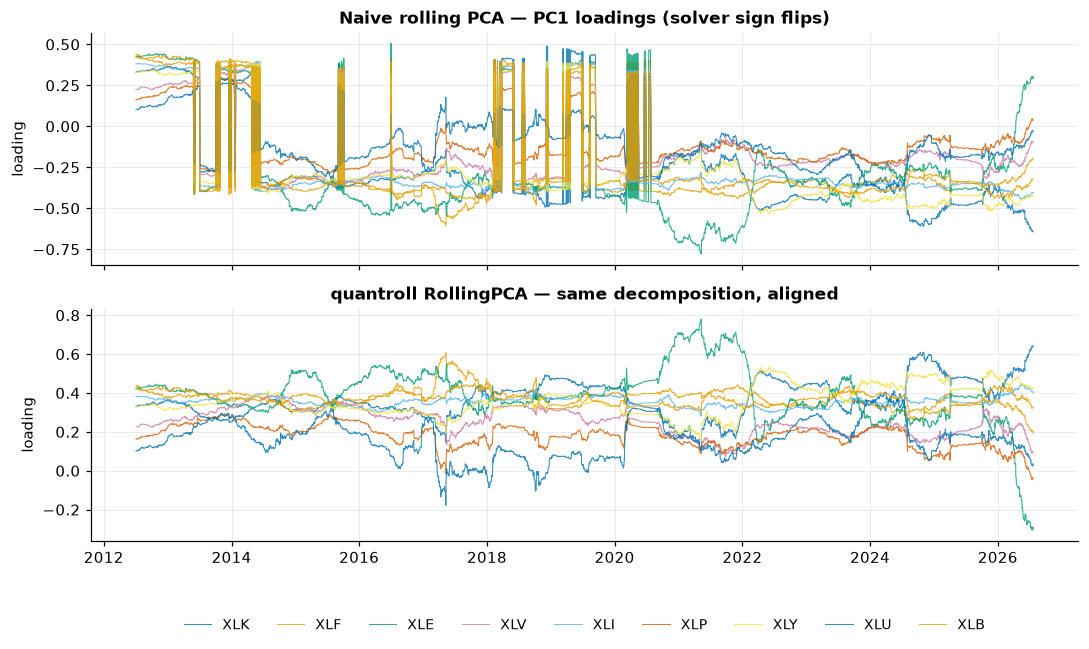

In [5]:
W, P = 126, 3
naive  = rolling_pca(R.to_numpy(), window=W, n_components=P, align=False)
stable = rolling_pca(R.to_numpy(), window=W, n_components=P)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for j, tkr in enumerate(sectors):
    axes[0].plot(R.index, naive.components[:, 0, j],  lw=0.7, alpha=0.8,
                 color=PAL[j % 7])
    axes[1].plot(R.index, stable.components[:, 0, j], lw=0.7, alpha=0.8,
                 color=PAL[j % 7], label=tkr)
axes[0].set_title("Naive rolling PCA — PC1 loadings (solver sign flips)")
axes[1].set_title("quantroll RollingPCA — same decomposition, aligned")
axes[1].set_ylabel("loading"); axes[0].set_ylabel("loading")
axes[1].legend(ncol=9, loc="lower center", bbox_to_anchor=(0.5, -0.45))
plt.tight_layout()

flips = int(stable.n_flips.sum())
reorders = int(stable.n_reorders.sum())
print(f"solver artifacts corrected over {R.shape[0]-W+1:,} windows: "
      f"{flips:,} sign flips, {reorders:,} component reorderings")

### How to read this

**Top panel (naive).** The vertical stripes are days on which the entire loading vector jumped to its mirror image — every loading multiplied by $-1$ — or on which PC2 or PC3 swapped into the PC1 slot. Nothing happened in markets on those days; the solver simply returned the other of the two equally valid answers. But anything built downstream of this series — a hedge ratio, a factor-momentum signal, a risk report — inverts randomly along with it.

**Bottom panel (aligned).** The mathematics is identical; the only change is that each window's components are matched to the previous window's before being reported. What remains is market information, and three features become readable that the top panel hides completely:

1. For nearly the entire decade, all nine loadings are *positive* — every sector participates in the common market factor, exactly what PC1 is supposed to capture. (The one exception is recent and real: energy's loading slips negative late in the sample — the same fact the section-1 table showed.)
2. The defensive sectors (XLP staples, XLU utilities, XLV health care) carry visibly *smaller* loadings than the cyclicals — they move with the market, but less.
3. The mix drifts *slowly* over the years as conditions change. That drift is genuine information about market structure, and it is only visible because the artificial jumps are gone.

The printed counts below the figure report exactly how many sign-flips and identity swaps alignment corrected — that is the number of artifacts a downstream model would otherwise have silently absorbed.

## 3. What the stable factors *are*: reading the loadings

Section 2 removed the artifacts. This section collects the first payoff of continuity: the components are no longer anonymous outputs of a solver but *objects with persistent meaning* — we can name them, read them, and watch that meaning evolve.

We focus on the second component. Recall why PC2 looks qualitatively different from PC1: it must be *uncorrelated* with PC1 — and since PC1 is "everything moves together," the only way to be uncorrelated with it is to be a *contrast*: long some sectors and short others, with loadings of both signs. PC2 is therefore the market's first *relative-value* axis — the dominant way sectors move *against* each other once the common market movement is set aside.

The heatmap below lays out PC2's loadings month by month. Because the component's identity is stable, which sectors it pairs against each other changes only slowly — and that change is itself information about what the market is currently trading on.

PC2 today — short side: XLV -0.45, XLP -0.44, XLU -0.40
PC2 today — long side:  XLY -0.12, XLE -0.10, XLK +0.46


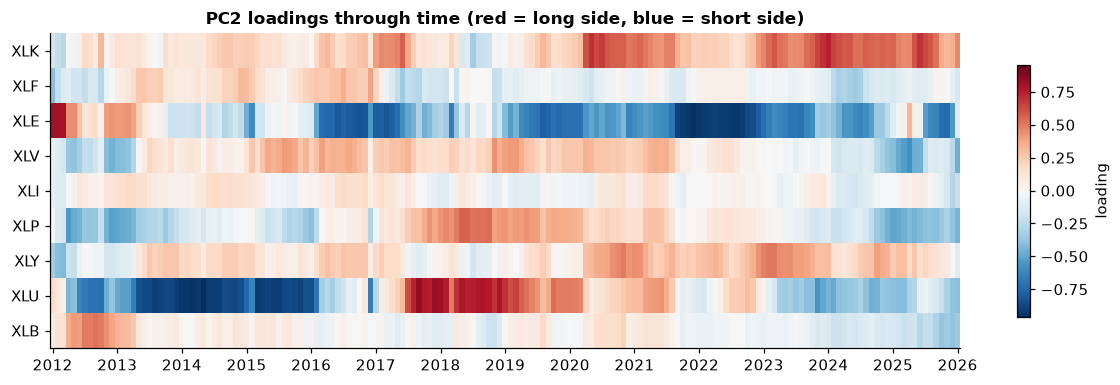

In [6]:
pc2 = pd.DataFrame(stable.components[:, 1, :], index=R.index, columns=sectors)
step = 21  # monthly slices for legibility
M = pc2.iloc[W-1::step].dropna().T

fig, ax = plt.subplots(figsize=(11, 3.6))
vmax = np.nanmax(np.abs(M.to_numpy()))
im = ax.imshow(M, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_yticks(range(len(sectors)), sectors)
xt = np.arange(0, M.shape[1], 12)
ax.set_xticks(xt, [d.strftime("%Y") for d in M.columns[xt]])
ax.set_title("PC2 loadings through time (red = long side, blue = short side)")
fig.colorbar(im, ax=ax, shrink=0.8, label="loading")
ax.grid(False)
plt.tight_layout()

last = pc2.dropna().iloc[-1].sort_values()
print("PC2 today — short side:", ", ".join(f"{t} {v:+.2f}" for t, v in last.head(3).items()))
print("PC2 today — long side: ", ", ".join(f"{t} {v:+.2f}" for t, v in last.tail(3).items()))

### How to read this

Each column of the heatmap is one month; each row is one sector. Red cells are sectors on the long side of the axis, blue cells on the short side, and the color intensity is the size of the loading.

- **Persistent horizontal bands** mean the axis has a stable meaning — for instance, energy sitting on one side while technology sits on the other, for years at a stretch. During such periods "PC2" is shorthand for a nameable trade.
- **A band changing color** is a genuine event: the axis has rotated, and what drives relative sector returns has changed. Such rotations are visible here *only because* component identity is pinned — on the naive version, sign flips scramble the colors and this chart is unreadable noise.

The printed line below the figure states the current composition of the axis in words — a ready-made sentence for a risk meeting: *"our second factor is currently long X and Y against short Z."*

## 4. The similarity trace: a free structure-change signal

Sections 2–3 used stability to read the factors *at each moment*. This section and the next use it for something the naive workflow cannot attempt at all: measuring *change itself*. The question "did the market's structure move today?" presupposes that today's answer and yesterday's are comparable — which is precisely what alignment guarantees. Conveniently, the machinery already computes the measurement for us.

To match components across windows, alignment computes, every day, the absolute cosine similarity between each of today's components and yesterday's — a number in $[0, 1]$ measuring the angle between the two axes. A value of 1 means "the same axis as yesterday"; lower values mean the axis has genuinely rotated. (Taking the absolute value makes the measure blind to the irrelevant sign.)

When the covariance structure is stable, similarity sits at ≈ 1.0 day after day. **Dips are days on which the factor structure genuinely rotated** — not solver noise, which alignment has already removed, but an actual reorganization of how sectors co-move. Below we plot the *worst* (minimum) similarity across the three components, smoothed with a 10-day rolling minimum, and mark several famous market crises in orange for comparison.

deepest structure-change episode per quarter (6 lowest):
  2012Q3: min similarity 0.787
  2013Q4: min similarity 0.660
  2014Q4: min similarity 0.779
  2017Q2: min similarity 0.734
  2019Q2: min similarity 0.541
  2019Q3: min similarity 0.541


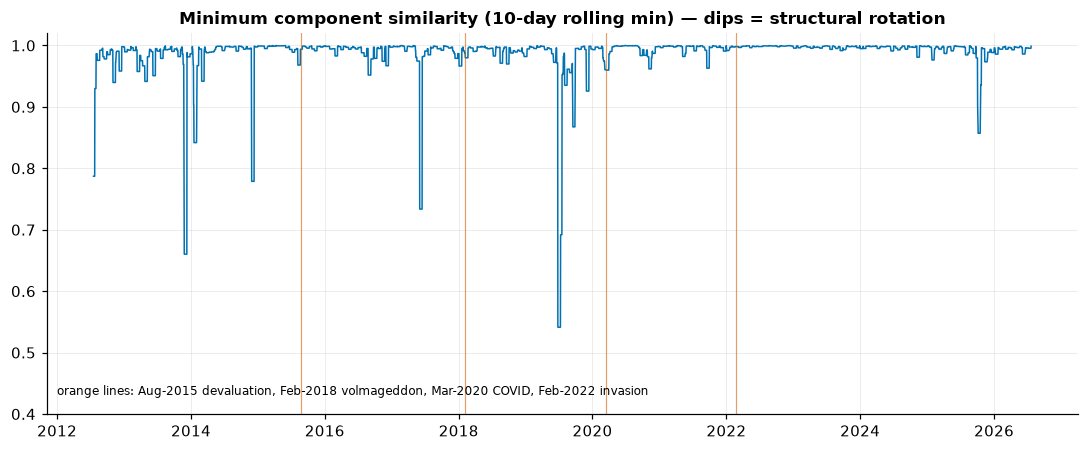

In [7]:
sim = pd.Series(np.nanmin(stable.similarity, axis=1), index=R.index)
roll = sim.rolling(10).min()

fig, ax = plt.subplots()
ax.plot(sim.index, roll, color=PAL[0], lw=1.0)
ax.set_ylim(0.4, 1.02)
ax.set_title("Minimum component similarity (10-day rolling min) — dips = structural rotation")
for d in ["2015-08-24", "2018-02-05", "2020-03-16", "2022-02-24"]:
    ax.axvline(pd.Timestamp(d), color=PAL[5], lw=0.8, alpha=0.6)
ax.text(0.01, 0.05, "orange lines: Aug-2015 devaluation, Feb-2018 volmageddon, "
        "Mar-2020 COVID, Feb-2022 invasion", transform=ax.transAxes, fontsize=8)
plt.tight_layout()

episodes = roll.resample("QE").min().nsmallest(6).sort_index()
print("deepest structure-change episode per quarter (6 lowest):")
for d, v in episodes.items():
    print(f"  {d.to_period('Q')}: min similarity {v:.3f}")

### How to read this — and a surprise worth understanding

Compare the printed list of deepest rotation episodes with the orange crisis markers: **they do not line up.** The deepest rotations in this sample occur in *calm* stretches — late 2013, mid-2017, mid-2019 (when collapsing interest rates flipped the defensive/cyclical axis) — not during the crashes.

At first glance this seems backwards: shouldn't a crisis be exactly when factor structure changes? The explanation is mechanical, and understanding it teaches you what each diagnostic is *for*:

- **In a crisis**, correlations rise toward one and PC1 absorbs most of the variance. The market factor becomes *more* sharply defined — its variance towers over the others — so there is no ambiguity about which axis is which, and the similarity stays *high*.
- **In quiet, differentiated markets**, the lower-ranked components have variances that sit close together. That is precisely when the relative-value axes can genuinely reorganize — market leadership rotates with no crash attached — and the similarity trace dips. Notice that no price-based monitor would show anything at all on those days.

The conclusion: the similarity trace is a **factor-rotation monitor, not a crash detector**. The crash gauge is the absorption ratio, the subject of the next section. The two answer complementary questions — *"are the axes reorganizing?"* versus *"is everything becoming one trade?"* — and a good dashboard shows both.

## 5. The absorption ratio: how much of the market is one trade?

The similarity trace answered "*are the axes reorganizing?*" Our second monitor answers the complementary question — "*is everything becoming one trade?*" — and, as the previous section showed, it is this one, not the similarity trace, that speaks in crises.

Every PCA reports the *proportion of variance explained* by each component. The proportion explained by PC1 — the market factor — deserves special attention here, because it measures how *concentrated* co-movement is. In finance this quantity is called the *absorption ratio*: the share of everything that happens across the nine sectors that is "absorbed" by the single common movement.

When absorption is high, one macro trade is driving everything: sector positions that look diversified are, for the moment, a single position, and shocks propagate freely across the market. When absorption is low, sectors are moving on their own fundamentals.

To see how absorption behaves, we plot it against the *drawdown* of SPY. A drawdown is the percentage decline from the highest level reached so far — how far "under water" the index is at each date; it is the standard way to display an index's painful episodes on one axis.

absorption today: 41% — 2% percentile of the past decade (typical range 43%-81%)
ann. SPY vol next month when absorption in top quintile: 22.1% vs otherwise 15.0%
avg fwd 21d SPY return | high absorption: +2.48% | otherwise: +0.98%


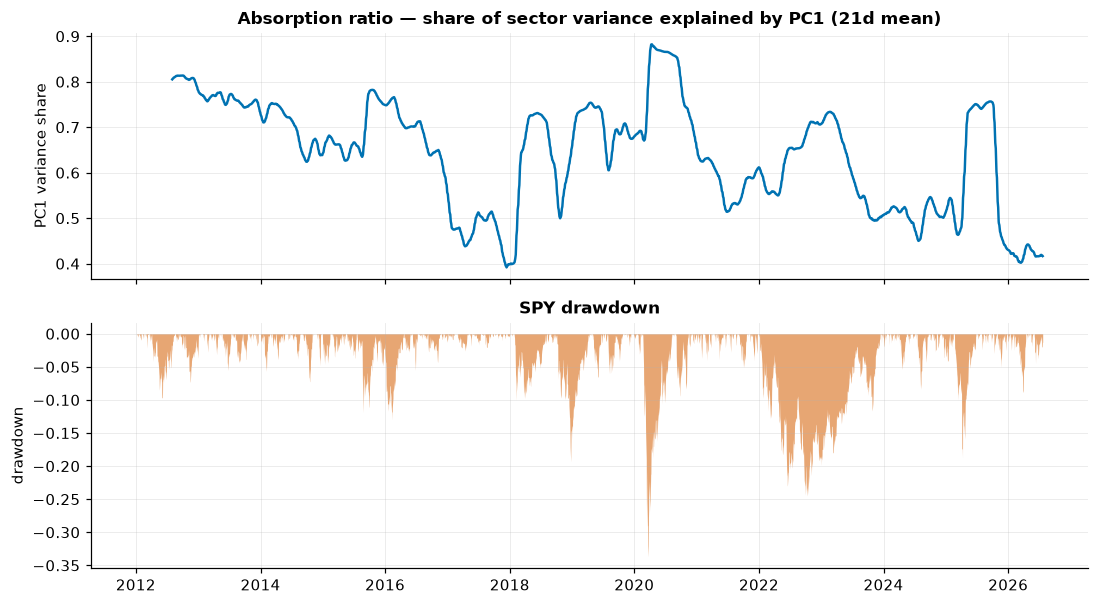

In [8]:
absorb = pd.Series(stable.explained_variance_ratio[:, 0], index=R.index)
spy = rets["SPY"].reindex(R.index)
wealth = (1 + spy).cumprod()
dd = wealth / wealth.cummax() - 1

fig, axes = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)
axes[0].plot(absorb.index, absorb.rolling(21).mean(), color=PAL[0])
axes[0].set_title("Absorption ratio — share of sector variance explained by PC1 (21d mean)")
axes[0].set_ylabel("PC1 variance share")
axes[1].fill_between(dd.index, dd, 0, color=PAL[5], alpha=0.55, lw=0)
axes[1].set_title("SPY drawdown")
axes[1].set_ylabel("drawdown")
plt.tight_layout()

hi = absorb > absorb.quantile(0.8)
fwd21 = spy.rolling(21).sum().shift(-21)
today = absorb.dropna().iloc[-1]
pct = (absorb < today).mean()
print(f"absorption today: {today:.0%} — {pct:.0%} percentile of the past decade "
      f"(typical range {absorb.quantile(0.05):.0%}-{absorb.quantile(0.95):.0%})")
print(f"ann. SPY vol next month when absorption in top quintile: "
      f"{spy[hi].std()*np.sqrt(252):.1%} vs otherwise {spy[~hi].std()*np.sqrt(252):.1%}")
print(f"avg fwd 21d SPY return | high absorption: {fwd21[hi].mean():+.2%} "
      f"| otherwise: {fwd21[~hi].mean():+.2%}")

### How to read this

Absorption spikes into and during every major drawdown of the decade — in a crisis, correlations go to one and PC1 eats the variance. Three practical readings:

1. **As a risk-dashboard number.** Report absorption next to VaR. High absorption means sector diversification is temporarily fictional — the nine positions are behaving as one — and position sizing should respect that.
2. **As a conditioning variable.** The printed comparison sorts history by absorption and asks what happened *in the following month*. Realized volatility is far higher after top-quintile absorption — a large, robust association. But look at the forward *return* line: it is typically *positive* after high absorption. This is not a contradiction. Absorption peaks in the depths of crises, and rebounds follow crises; high forward volatility together with positive forward return is the signature of a crisis-rebound premium. This is why absorption belongs in the *risk* block of a process (size and hedge with it), not the *alpha* block (do not naively sell on it).
3. **As a reading for today.** Check the printed percentile. Very low absorption — as at the time of writing — is the mirror condition: sectors trading on their own fundamentals, a stock-picker's market, diversification actually delivering.

One final point: none of this is reliably computable from the naive decomposition. When PC1's identity flips or swaps with PC2, the "variance share of PC1" series silently mixes the shares of *different* components — the very quantity being charted loses its meaning.

## 6. EWMA weighting: reactive risk without a hard window edge

Both monitors so far took the estimator's window for granted. But the window is itself a modeling decision — *how should the recent past be weighted?* — and the flat window's implicit answer has a failure mode worth understanding.

A flat 126-day window treats a shock that happened 125 days ago and a shock that happened yesterday as equally important — and then, one day later, forgets the older shock *entirely*. Measured risk therefore *drops* on the one-window anniversary of a crash, for no reason connected to today's market. Practitioners call this the "ghost in the window."

The standard cure is to replace the flat window with *exponentially decaying weights*: every observation's influence shrinks by a fixed fraction per day, so old data fades smoothly instead of falling off a cliff. The `halflife=` parameter expresses the decay in intuitive units — `halflife=42` means an observation 42 trading days old carries exactly half the weight of today's. (This is the same weighting scheme as the classic RiskMetrics volatility estimator.)

The figure below compares the two absorption series through the COVID crash. The flat window carries the shock at full strength for six months and then abruptly drops it; the EWMA version reacts faster on the way in and decays gracefully on the way out.

note the flat window's cliff ~126 trading days after the March-2020 shock;
the EWMA version decays smoothly instead.


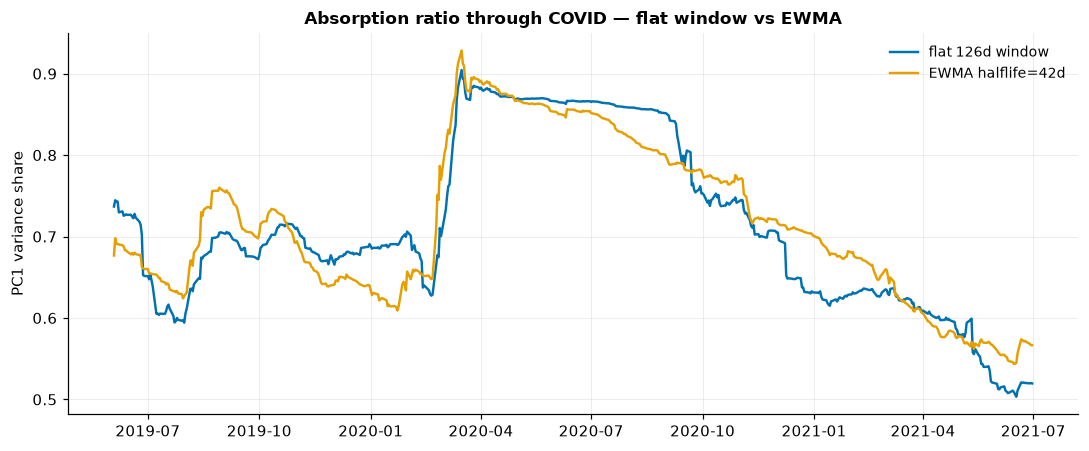

In [9]:
ew = rolling_pca(R.to_numpy(), window=W, n_components=P, halflife=42.0)
a_flat = pd.Series(stable.explained_variance_ratio[:, 0], index=R.index)
a_ew   = pd.Series(ew.explained_variance_ratio[:, 0], index=R.index)

sl = slice("2019-06", "2021-06")
fig, ax = plt.subplots()
ax.plot(a_flat[sl].index, a_flat[sl], label="flat 126d window", color=PAL[0])
ax.plot(a_ew[sl].index,  a_ew[sl],  label="EWMA halflife=42d", color=PAL[1])
ax.set_title("Absorption ratio through COVID — flat window vs EWMA")
ax.set_ylabel("PC1 variance share"); ax.legend()
plt.tight_layout()
print("note the flat window's cliff ~126 trading days after the March-2020 shock;")
print("the EWMA version decays smoothly instead.")

## 7. Variable universes: real ETFs launching mid-sample

One obstacle still separates everything above from an honest decade-long backtest: real universes do not hold still — assets launch, merge, and delist. Our sample contains two genuine examples: XLRE (real estate) was carved out of XLF in **October 2015**, and XLC (communication services) out of XLK/XLY in **June 2018**.

`RollingPCA` accepts this directly, with a simple convention: a `NaN` in the input means *this asset does not exist on this day*. Each window then decomposes only the assets fully observed within it. The important design point is in the alignment step: components are matched across consecutive windows using only the assets the two windows *share*. Factor identity therefore survives membership changes — the market factor stays the market factor while the universe grows from 9 to 10 to 11 names.

XLRE: first return 2015-10-09, joins the decomposition 2016-04-11, min similarity around the join 0.8484
XLC: first return 2018-06-20, joins the decomposition 2018-12-18, min similarity around the join 0.9575


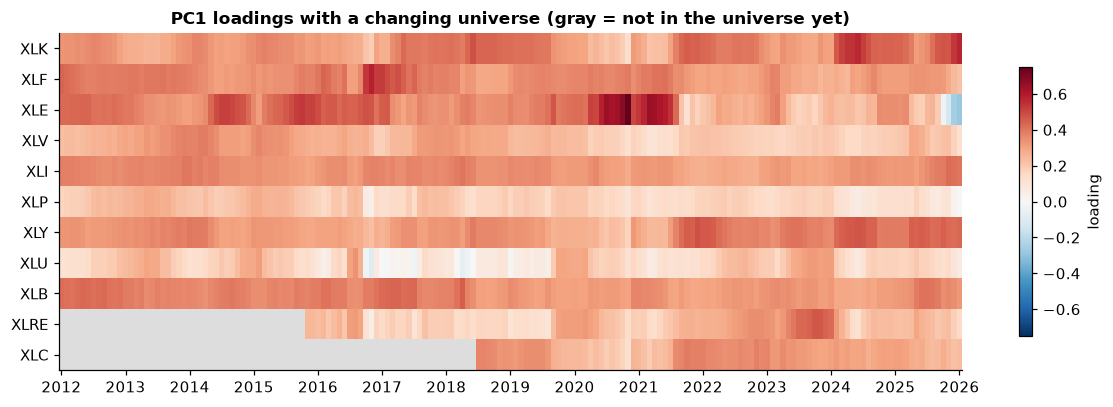

In [10]:
uni = qd.SECTOR_ETFS + ["XLRE", "XLC"]
Rv = rets[uni]                       # XLRE/XLC are NaN before inception
pca_v = RollingPCA(n_components=3, window=W).fit(Rv)
res = pca_v.result_

pc1 = pd.DataFrame(res.components[:, 0, :], index=Rv.index, columns=uni)
Mv = pc1.iloc[W-1::step].T
A = np.ma.masked_invalid(Mv.to_numpy())
fig, ax = plt.subplots(figsize=(11, 3.8))
cmap = plt.get_cmap("RdBu_r").copy(); cmap.set_bad("#dddddd")
vmax = np.nanmax(np.abs(Mv.to_numpy()))
im = ax.imshow(A, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
ax.set_yticks(range(len(uni)), uni)
xt = np.arange(0, Mv.shape[1], 12)
ax.set_xticks(xt, [d.strftime("%Y") for d in Mv.columns[xt]])
ax.set_title("PC1 loadings with a changing universe (gray = not in the universe yet)")
fig.colorbar(im, ax=ax, shrink=0.8, label="loading")
ax.grid(False)
plt.tight_layout()

sim_v = pd.Series(np.nanmin(res.similarity, axis=1), index=Rv.index)
for tkr in ["XLRE", "XLC"]:
    first = Rv[tkr].first_valid_index()
    join = Rv.index[Rv.index.get_loc(first) + W - 1]
    around = sim_v.loc[join - pd.Timedelta(days=10): join + pd.Timedelta(days=10)]
    print(f"{tkr}: first return {first.date()}, joins the decomposition {join.date()}, "
          f"min similarity around the join {around.min():.4f}")

### How to read this

The gray blocks in the heatmap are simply *before inception* — no data exists there. Reading left to right, the decomposition runs on 9 assets, then 10, then 11, with no special handling on our part.

The printed similarity values around each join measure how disruptive each membership change actually was — and the two events differ in an instructive way:

- **XLC joins almost seamlessly** (minimum similarity ≈ 0.96). Communications stocks were already inside the universe, held within the tech and consumer-discretionary ETFs, so adding XLC introduced almost no co-movement structure the factors had not already captured.
- **XLRE causes a modest one-time adjustment** (minimum similarity ≈ 0.85). Real estate genuinely added a dimension the old universe did not span, so the factor axes had to rotate slightly to make room for it.

Crucially, in neither case does identity *scramble*: the adjustment is a one-time rotation, not a relabeling, and the market factor remains recognizably itself through the join. This matters because every honest decade-long backtest contains universe entries and exits — a tool that cannot absorb them is a research toy, not a production tool.

## 8. Production ergonomics: streaming and speed

The final question is operational: what does it cost to run all of the above every morning, forever?

Not a refit of ten years of history. You call `update()` with the newest row: the rolling covariance is adjusted in place (add the newest day, drop the oldest — a small $O(d^2)$ arithmetic step) and one small eigensolve produces the new components.

The cell below verifies the property that makes this trustworthy: fitting the first part of the history and then streaming in the last 60 days one at a time gives *exactly* the same output as fitting everything in one batch. It also times a full ten-year refit — well under a second, thanks to the compiled (Numba) rolling kernel and the warm-started eigensolver.

In [11]:
import time

full = RollingPCA(n_components=3, window=W).fit(R)
part = RollingPCA(n_components=3, window=W).fit(R.iloc[:-60])
part.update(R.iloc[-60:])
same = np.allclose(part.transform().to_numpy(), full.transform().to_numpy(),
                   rtol=1e-6, atol=1e-9, equal_nan=True)
print(f"fit(head) + update(60 days) == fit(everything): {same}")

t0 = time.perf_counter(); rolling_pca(R.to_numpy(), window=W, n_components=3)
print(f"full 10-year refit, {R.shape[0]:,} windows: {time.perf_counter()-t0:.3f}s")

fit(head) + update(60 days) == fit(everything): True
full 10-year refit, 3,657 windows: 0.039s


## What you now have, and what it's worth

A summary of the outputs this notebook produced, and what each one is for:

| Output | Use it for |
|---|---|
| Stable PC1 loadings & projections | market-factor hedging weights that don't invert overnight; factor-return series for risk models |
| PC2/PC3 loadings heatmap | a live answer to "what is the market differentiating on right now?" |
| Similarity trace | correlation-structure early warning; flags factor rotation that no price chart shows |
| Absorption ratio | systemic-risk gauge; conditions position sizing and tests diversification claims |
| EWMA mode | reactive risk estimates without window-anniversary artifacts |
| Variable universes | honest decade-long backtests with real universe entries and exits |
| `update()` streaming | daily production runs in microseconds, provably identical to batch |

Notice the shape of this list: only the first row is about *fixing* something. Every other row is a capability that simply did not exist in the naive workflow — structure-change monitors, a systemic-risk gauge, honest backtests, streaming jobs — all purchased by the single property of *continuity of identity*. That is what we meant at the top by "stability turns analytics into infrastructure," and it is the pattern the rest of the series repeats with different models.

**Next notebooks:** `02` detects calm/turbulent *regimes* with a rolling hidden Markov model; `03` builds stable *peer groups* of stocks; `04` draws a stable *map* of the equity universe; `05` turns 13 performance measures into one *explainable scorecard*.